# Clasificación de Candidatos a Exoplaneta (Kepler KOI)
## NASA Kepler Objects of Interest — Cumulative Table

**Autor:** Jheison Martinez Bolivar
**Maestría:** Inteligencia Artificial
**Fecha:** Agosto 2026
**Dataset:** [Kepler Exoplanet Search Results – Kaggle](https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results)

---

### Planteamiento del Proyecto
Continuando con la línea de trabajo de la Actividad 1 (regresión sobre excentricidad orbital), en este cuaderno abordamos un problema de **clasificación supervisada** en el mismo dominio astronómico, pero con un dataset distinto: el catálogo acumulativo de **Kepler Objects of Interest (KOI)**.

A diferencia del dataset de la [Actividad 1](https://colab.research.google.com/drive/1UB8g-jYuwyeEerVtnyryVKVM9uYLOb07?usp=sharing) donde encontramos que las variables categóricas eran en realidad reglas deterministas sobre columnas numéricas ya presentes, este catálogo plantea un problema de clasificación genuino.

Antes de definir las features finales, haremos un EDA para revisar la estructura del dataset, los valores nulos, y las columnas que deberán tratarse.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")
print("✓ Librerías cargadas")

✓ Librerías cargadas


## 1. Exploración de Datos (EDA)

In [2]:
# ── 2. Carga de datos ───────────────────────────────────────────────────────
path = kagglehub.dataset_download("nasa/kepler-exoplanet-search-results")
df_raw = pd.read_csv(path + "/cumulative.csv")

print(f"Dataset: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print()
df_raw.head(3)

Dataset: 9,564 filas x 50 columnas



,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436


=== Distribución del target: koi_disposition ===
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

Distribución en %:
koi_disposition
FALSE POSITIVE    52.52
CONFIRMED         23.98
CANDIDATE         23.50
Name: proportion, dtype: float64


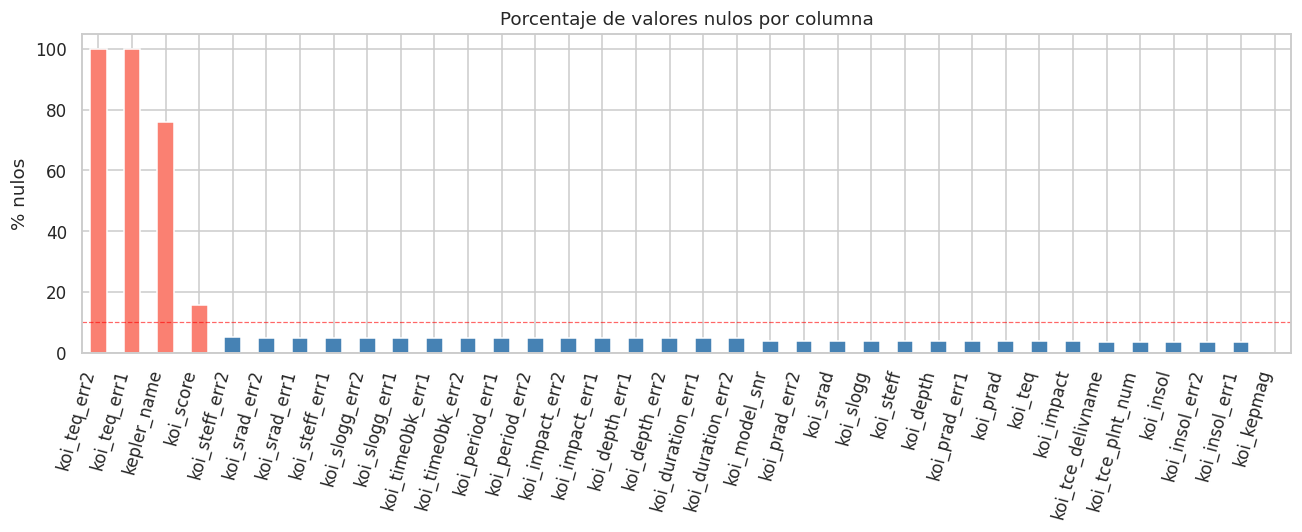


Variables con nulos:
koi_teq_err2         100.00
koi_teq_err1         100.00
kepler_name           76.01
koi_score             15.79
koi_steff_err2         5.05
koi_srad_err2          4.89
koi_srad_err1          4.89
koi_steff_err1         4.89
koi_slogg_err2         4.89
koi_slogg_err1         4.89
koi_time0bk_err1       4.75
koi_time0bk_err2       4.75
koi_period_err1        4.75
koi_period_err2        4.75
koi_impact_err2        4.75
koi_impact_err1        4.75
koi_depth_err1         4.75
koi_depth_err2         4.75
koi_duration_err1      4.75
koi_duration_err2      4.75
koi_model_snr          3.80
koi_prad_err2          3.80
koi_srad               3.80
koi_slogg              3.80
koi_steff              3.80
koi_depth              3.80
koi_prad_err1          3.80
koi_prad               3.80
koi_teq                3.80
koi_impact             3.80
koi_tce_delivname      3.62
koi_tce_plnt_num       3.62
koi_insol              3.36
koi_insol_err2         3.36
koi_insol_err1         3.3

In [3]:
# ── 3. Análisis de columnas y valores nulos ─────────────────────────────────
print("=== Distribución del target: koi_disposition ===")
print(df_raw["koi_disposition"].value_counts())
print()
print("Distribución en %:")
print((df_raw["koi_disposition"].value_counts(normalize=True) * 100).round(2))

null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
null_pct_nonzero = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["salmon" if v > 10 else "steelblue" for v in null_pct_nonzero.values]
null_pct_nonzero.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
ax.set_title("Porcentaje de valores nulos por columna", fontsize=12)
ax.set_ylabel("% nulos")
ax.axhline(10, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

print()
print("Variables con nulos:")
print(null_pct_nonzero.round(2).to_string())

En el gráfico anterior, `koi_score` tiene 15% de nulos aprox, primero pense que podria ser buen candidato para ser nuestro feature a clasificar, pero que tenga pocos nulos **no la hace necesariamente una buena candidata** hay que hacerse otra pregunta, aparte de "¿cuántos datos le faltan?": **¿esta columna ya contiene la respuesta que quiero predecir?**

`koi_score` es la nota de confianza que el propio sistema automático de la NASA le puso a cada KOI para decidir si es un planeta real o no. Es literalmente el resultado de otro clasificador ya aplicado sobre este mismo problema. No la usamos para nuesstro modelo porque eso no es aprender del fenómeno, seria copiar la respuesta de otro modelo.

Lo mismo pasa con `koi_pdisposition` (una disposición preliminar que casi siempre coincide con la final) y con `kepler_name` (solo se llena cuando el planeta ya fue confirmado — si tiene nombre, ya sabés la respuesta).

**La regla práctica que vamos a usar de acá en adelante:** al elegir features, no alcanza con mirar el % de nulos. Hay que preguntarse si la columna describe la *señal observada* (el tránsito, la estrella) o si describe *una conclusión ya tomada* sobre esa señal. Las primeras son features válidas; las segundas se descartan sin importar qué tan "completas" se vean.

Ya vimos arriba que el target es `koi_disposition` (las 3 clases: CONFIRMED, CANDIDATE, FALSE POSITIVE), esa parte no la elegimos nosotros, viene así en el catálogo de la NASA.

Lo que sí toca decidir es qué columnas le paso al modelo como features. Voy descartando por lo que fui encontrando en las celdas anteriores:

- `koi_score`, `koi_pdisposition`, `kepler_name`: fuera, es la respuesta ya calculada.
- `koi_teq_err1`, `koi_teq_err2`: fuera, estaban 100% vacías.
- `rowid`, `kepid`, `kepoi_name`, `koi_tce_delivname`: fuera, son identificadores/nombres, no describen nada físico del planeta ni la estrella.
- `ra`, `dec`, las columnas `*_err1`/`*_err2` de margen de error, y `koi_tce_plnt_num`: las dejo afuera por ahora para no inflar el set con variables de incertidumbre que no aportan directamente a decidir si es un planeta o un falso positivo.

Con eso me quedan 17 columnas: las 4 banderas de vetting (`koi_fpflag_*`, que no son deterministas) más las mediciones del tránsito y de la estrella.

In [4]:
TARGET = "koi_disposition"

FEATURES = [
    "koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec",
    "koi_period", "koi_time0bk", "koi_impact", "koi_duration", "koi_depth",
    "koi_prad", "koi_teq", "koi_insol", "koi_model_snr",
    "koi_steff", "koi_slogg", "koi_srad", "koi_kepmag",
]

print(f"Total features seleccionadas: {len(FEATURES)}")
print()
print("Nulos dentro del set seleccionado:")
print((df_raw[FEATURES + [TARGET]].isnull().sum()).sort_values(ascending=False).to_string())

n_completas = df_raw[FEATURES + [TARGET]].dropna().shape[0]
print()
print(f"Filas completas tras dropna: {n_completas:,} de {len(df_raw):,} ({n_completas/len(df_raw)*100:.1f}%)")

Total features seleccionadas: 17

Nulos dentro del set seleccionado:
koi_prad           363
koi_depth          363
koi_slogg          363
koi_steff          363
koi_impact         363
koi_srad           363
koi_model_snr      363
koi_teq            363
koi_insol          321
koi_kepmag           1
koi_fpflag_ss        0
koi_fpflag_nt        0
koi_duration         0
koi_time0bk          0
koi_fpflag_co        0
koi_fpflag_ec        0
koi_period           0
koi_disposition      0

Filas completas tras dropna: 9,200 de 9,564 (96.2%)


## Distribución del Target y Correlación entre Features

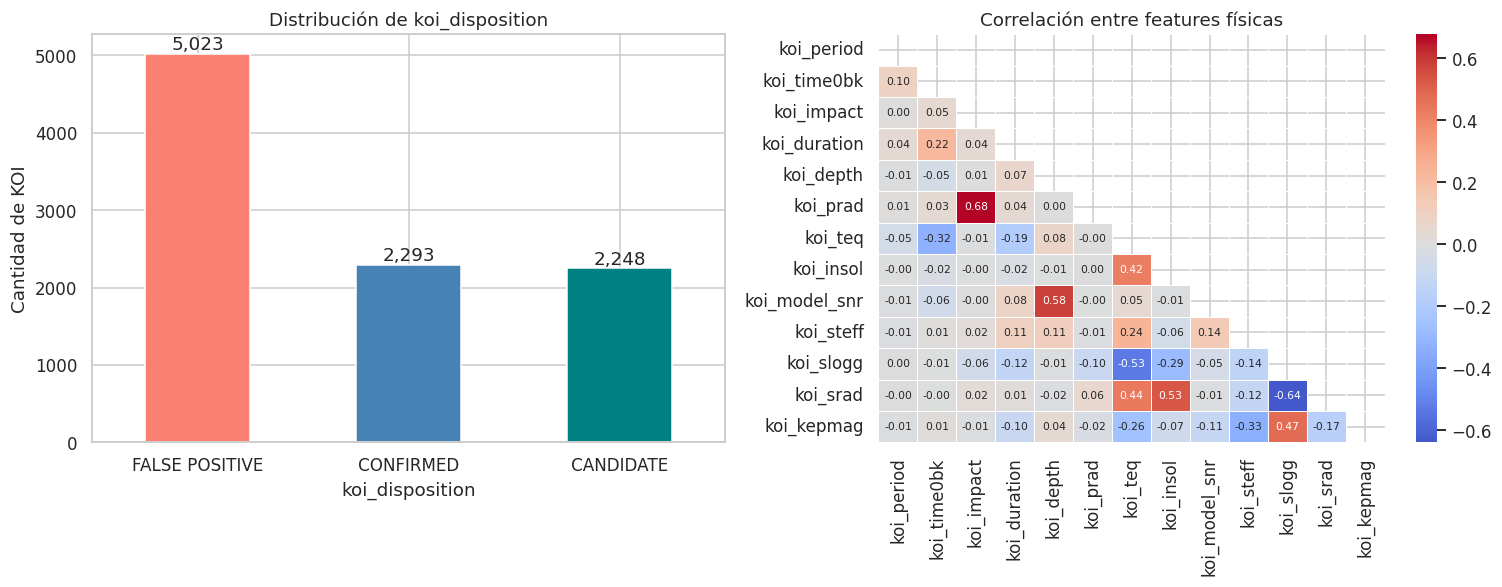

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

conteo = df_raw["koi_disposition"].value_counts()
conteo.plot(kind="bar", ax=axes[0], color=["salmon", "steelblue", "teal"], edgecolor="white")
axes[0].set_title("Distribución de koi_disposition")
axes[0].set_ylabel("Cantidad de KOI")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center")

corr_features = [f for f in FEATURES if not f.startswith("koi_fpflag")]
corr = df_raw[corr_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[1], linewidths=0.4, annot_kws={"size": 7})
axes[1].set_title("Correlación entre features físicas")

plt.tight_layout()
plt.show()

## Distribución de Features Clave por Clase

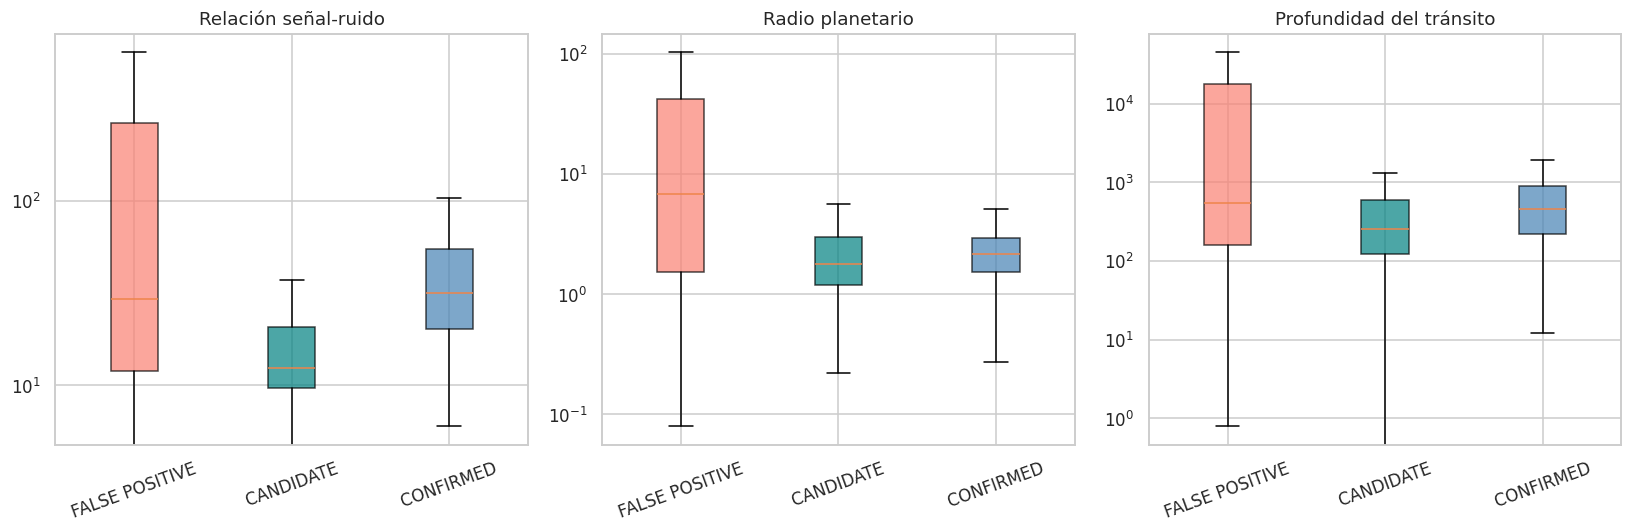

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_plot = df_raw.dropna(subset=["koi_model_snr", "koi_prad", "koi_depth"])
orden = ["FALSE POSITIVE", "CANDIDATE", "CONFIRMED"]
colores = {"FALSE POSITIVE": "salmon", "CANDIDATE": "teal", "CONFIRMED": "steelblue"}

for ax, col, titulo in zip(
    axes,
    ["koi_model_snr", "koi_prad", "koi_depth"],
    ["Relación señal-ruido", "Radio planetario", "Profundidad del tránsito"],
):
    datos = [df_plot.loc[df_plot["koi_disposition"] == c, col] for c in orden]
    bp = ax.boxplot(datos, labels=orden, patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], orden):
        patch.set_facecolor(colores[c])
        patch.set_alpha(0.7)
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=20)
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

## 2. Preprocesamiento de Datos

In [7]:
df = df_raw[FEATURES + [TARGET]].dropna()
print(f"Filas después de dropna: {len(df):,} (de {len(df_raw):,} originales)")
print(f"Filas eliminadas: {len(df_raw) - len(df):,} ({(1 - len(df)/len(df_raw))*100:.1f}%)")

y = df[TARGET]
X = df[FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("✓ Preprocesamiento y escalado completados con éxito")

Filas después de dropna: 9,200 (de 9,564 originales)
Filas eliminadas: 364 (3.8%)
Train: 7,360 | Test: 1,840
✓ Preprocesamiento y escalado completados con éxito


### ¿Qué estamos clasificando exactamente?

El telescopio Kepler detecta planetas de una forma indirecta: mira una estrella durante mucho tiempo y busca pequeñas caídas de brillo, que pasan cuando algo cruza por delante de la estrella (un "tránsito"). El problema es que no toda caída de brillo es un planeta — puede ser una estrella binaria, ruido del instrumento, u otro fenómeno que se ve parecido.

Por eso cada detección (cada KOI, "Kepler Object of Interest") queda etiquetada con `koi_disposition`, que es justamente el veredicto sobre esa señal:

- **CONFIRMED**: ya se verificó que es un planeta real.
- **CANDIDATE**: pinta como planeta, pero todavía no se ha confirmado.
- **FALSE POSITIVE**: la señal se parecía a un planeta, pero se descartó (era otra cosa).

Elegimos esta columna como target porque es exactamente el problema real que enfrentan los astrónomos: con miles de señales detectadas, no pueden confirmar una por una a mano, necesitan un modelo que les ayude a filtrar cuáles vale la pena revisar.

Entonces, lo que vamos a hacer es: usar las 17 features que preparamos (las banderas de vetting + las mediciones del tránsito y de la estrella) para que el modelo prediga a cuál de esas 3 categorías pertenece cada KOI.

## 3. Regresión Logística

Empezamos con este modelo como línea base: es de los más simples para clasificar, y nos sirve de punto de comparación para saber si Naive Bayes (el siguiente modelo) realmente mejora algo.

In [8]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average="weighted")
rec_lr  = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr   = f1_score(y_test, y_pred_lr, average="weighted")
cv_lr   = cross_val_score(lr, scaler.transform(X), y, cv=5, scoring="accuracy")

print("=== Regresión Logística ===")
print(f"Accuracy   (test):  {acc_lr:.4f}")
print(f"Precision  (test):  {prec_lr:.4f}")
print(f"Recall     (test):  {rec_lr:.4f}")
print(f"F1-score   (test):  {f1_lr:.4f}")
print(f"Accuracy CV-5fold:  {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}")
print()
print(classification_report(y_test, y_pred_lr))

=== Regresión Logística ===
Accuracy   (test):  0.8245
Precision  (test):  0.8244
Recall     (test):  0.8245
F1-score   (test):  0.8218
Accuracy CV-5fold:  0.7983 +/- 0.0154

                precision    recall  f1-score   support

     CANDIDATE       0.67      0.54      0.60       437
     CONFIRMED       0.64      0.75      0.69       458
FALSE POSITIVE       0.98      0.99      0.99       945

      accuracy                           0.82      1840
     macro avg       0.77      0.76      0.76      1840
  weighted avg       0.82      0.82      0.82      1840



## 4. Naive Bayes

Este modelo asume que las features son independientes entre sí (probablemente no es del todo cierto acá: cosas como profundidad y radio del planeta están relacionadas), pero aun así suele funcionar bien en la práctica. Usamos la versión Gaussiana (`GaussianNB`), pensada para features numéricas continuas como las nuestras.

In [9]:
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average="weighted")
rec_nb  = recall_score(y_test, y_pred_nb, average="weighted")
f1_nb   = f1_score(y_test, y_pred_nb, average="weighted")
cv_nb   = cross_val_score(nb, scaler.transform(X), y, cv=5, scoring="accuracy")

print("=== Naive Bayes ===")
print(f"Accuracy   (test):  {acc_nb:.4f}")
print(f"Precision  (test):  {prec_nb:.4f}")
print(f"Recall     (test):  {rec_nb:.4f}")
print(f"F1-score   (test):  {f1_nb:.4f}")
print(f"Accuracy CV-5fold:  {cv_nb.mean():.4f} +/- {cv_nb.std():.4f}")
print()
print(classification_report(y_test, y_pred_nb))

=== Naive Bayes ===
Accuracy   (test):  0.7087
Precision  (test):  0.8615
Recall     (test):  0.7087
F1-score   (test):  0.6416
Accuracy CV-5fold:  0.7078 +/- 0.0312

                precision    recall  f1-score   support

     CANDIDATE       0.45      0.98      0.62       437
     CONFIRMED       1.00      0.01      0.03       458
FALSE POSITIVE       0.98      0.92      0.95       945

      accuracy                           0.71      1840
     macro avg       0.81      0.64      0.53      1840
  weighted avg       0.86      0.71      0.64      1840



## 5. Random Forest

El enunciado también permite sumar otro modelo supervisado, y agregamos Random Forest porque no asume ni independencia entre features (a diferencia de Naive Bayes) ni fronteras lineales (a diferencia de Regresión Logística). Entrena muchos árboles de decisión sobre subconjuntos de datos y variables, y promedia sus votos para decidir la clase final.

In [10]:
rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="weighted")
rec_rf  = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf   = f1_score(y_test, y_pred_rf, average="weighted")
cv_rf   = cross_val_score(rf, X, y, cv=5, scoring="accuracy")

print("=== Random Forest (n_estimators=100) ===")
print(f"Accuracy   (test):  {acc_rf:.4f}")
print(f"Precision  (test):  {prec_rf:.4f}")
print(f"Recall     (test):  {rec_rf:.4f}")
print(f"F1-score   (test):  {f1_rf:.4f}")
print(f"Accuracy CV-5fold:  {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}")
print()
print(classification_report(y_test, y_pred_rf))

=== Random Forest (n_estimators=100) ===
Accuracy   (test):  0.8946
Precision  (test):  0.8939
Recall     (test):  0.8946
F1-score   (test):  0.8942
Accuracy CV-5fold:  0.8752 +/- 0.0500

                precision    recall  f1-score   support

     CANDIDATE       0.79      0.78      0.78       437
     CONFIRMED       0.80      0.81      0.80       458
FALSE POSITIVE       0.99      0.99      0.99       945

      accuracy                           0.89      1840
     macro avg       0.86      0.86      0.86      1840
  weighted avg       0.89      0.89      0.89      1840



## 6. Comparación de Modelos

                     Accuracy Test  Precision  Recall  F1-score         CV-5fold
Modelo                                                                          
Regresión Logística         0.8245     0.8244  0.8245    0.8218  0.7983+/-0.0154
Naive Bayes                 0.7087     0.8615  0.7087    0.6416  0.7078+/-0.0312
Random Forest               0.8946     0.8939  0.8946    0.8942  0.8752+/-0.0500



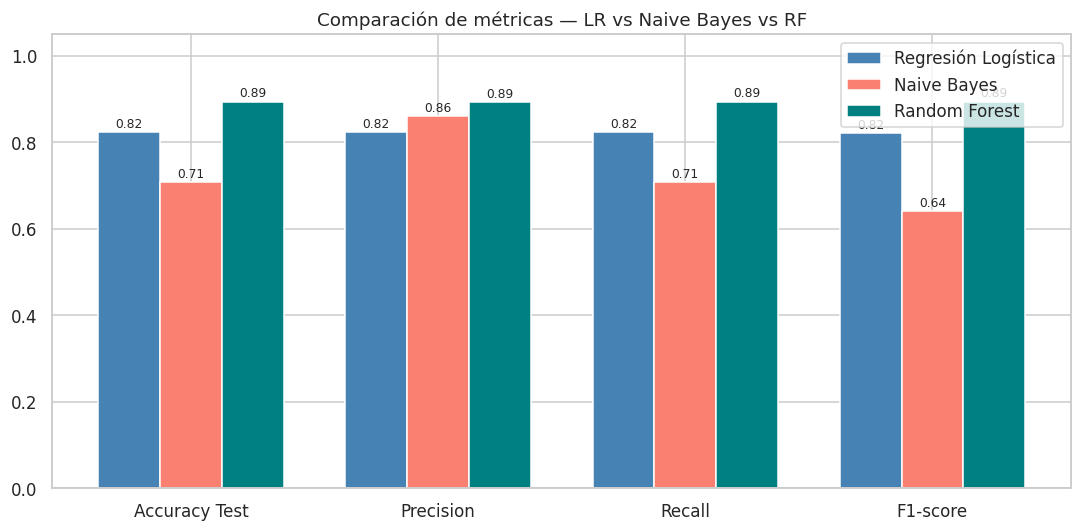

In [11]:
results = pd.DataFrame({
    "Modelo":       ["Regresión Logística", "Naive Bayes", "Random Forest"],
    "Accuracy Test":[round(acc_lr, 4),  round(acc_nb, 4),  round(acc_rf, 4)],
    "Precision":    [round(prec_lr, 4), round(prec_nb, 4), round(prec_rf, 4)],
    "Recall":       [round(rec_lr, 4),  round(rec_nb, 4),  round(rec_rf, 4)],
    "F1-score":     [round(f1_lr, 4),   round(f1_nb, 4),   round(f1_rf, 4)],
    "CV-5fold":     [f"{cv_lr.mean():.4f}+/-{cv_lr.std():.4f}",
                     f"{cv_nb.mean():.4f}+/-{cv_nb.std():.4f}",
                     f"{cv_rf.mean():.4f}+/-{cv_rf.std():.4f}"],
})
print(results.set_index("Modelo").to_string())
print()

fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["Accuracy Test", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
w = 0.25

vals_lr = [acc_lr, prec_lr, rec_lr, f1_lr]
vals_nb = [acc_nb, prec_nb, rec_nb, f1_nb]
vals_rf = [acc_rf, prec_rf, rec_rf, f1_rf]

b1 = ax.bar(x - w, vals_lr, w, label="Regresión Logística", color="steelblue")
b2 = ax.bar(x,     vals_nb, w, label="Naive Bayes",         color="salmon")
b3 = ax.bar(x + w, vals_rf, w, label="Random Forest",       color="teal")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title("Comparación de métricas — LR vs Naive Bayes vs RF", fontsize=12)
ax.legend()
for bar in list(b1) + list(b2) + list(b3):
    ax.annotate(f"{bar.get_height():.2f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Conclusiones

1. **Random Forest ganó, y no por poco**: 89.5% de accuracy contra 82.5% de Regresión Logística y 70.9% de Naive Bayes. Pero el número que más nos convenció no fue el accuracy general, sino mirar clase por clase — ahí es donde Random Forest realmente se despega, prediciendo bien tanto CANDIDATE como CONFIRMED, mientras que los otros dos se les complicaba justo esas dos clases.

2. **El accuracy general engaña si no lo desglosamos**: los tres modelos acertaban casi siempre en FALSE POSITIVE (más de la mitad del dataset), así que un modelo mediocre igual podía sacar buen accuracy solo por acertar la clase fácil. El problema real estaba en distinguir CANDIDATE de CONFIRMED, que se parecen mucho en sus mediciones — ahí sí se notó la diferencia entre modelos.

3. **Por qué le fue tan mal a Naive Bayes**: asume que las features no se relacionan entre sí, y en nuestro caso sí se relacionan (por ejemplo, qué tan profunda se ve la caída de brillo depende del tamaño del planeta). Cuando esa relación existe y el modelo la ignora, termina prediciendo casi siempre la misma clase (le pasó con CONFIRMED, que casi nunca lo detectó).

4. **Por qué le fue mejor a Random Forest**: no depende de que las variables sean independientes ni de que la relación sea una línea recta. Al combinar muchos árboles que miran combinaciones distintas de las variables, logra capturar patrones más complejos — como que una señal sea candidata a planeta dependiendo de la combinación de varias medidas a la vez, no de una sola por separado.

5. **Aplicación práctica**: esto reproduce el problema real que tiene la misión Kepler — con miles de señales detectadas, no alcanza para que un humano revise cada una a mano. Un modelo como Random Forest podría usarse para priorizar cuáles candidatos vale la pena que un astrónomo revise primero, en lugar de reemplazar la revisión humana por completo.

### Referencias
- Kepler Objects of Interest (KOI) — NASA Exoplanet Archive: https://exoplanetarchive.ipac.caltech.edu/
- Dataset: https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results

## 8. Ejemplo de Inferencia sobre Datos No Vistos

Hasta acá solo miramos métricas agregadas del conjunto de prueba. Pero vale la pena ver el modelo funcionando caso por caso: tomamos algunas filas de `X_test` (el modelo nunca las usó para entrenar) y comparamos qué predijo cada modelo contra la etiqueta real.

In [12]:
np.random.seed(7)
idx_muestra = np.random.choice(X_test.index, size=8, replace=False)

X_muestra = X_test.loc[idx_muestra]
X_muestra_sc = scaler.transform(X_muestra)

pred_lr = lr.predict(X_muestra_sc)
pred_nb = nb.predict(X_muestra_sc)
pred_rf = rf.predict(X_muestra)

comparacion = pd.DataFrame({
    "Real": y_test.loc[idx_muestra].values,
    "Pred. Reg. Logística": pred_lr,
    "Pred. Naive Bayes": pred_nb,
    "Pred. Random Forest": pred_rf,
}, index=idx_muestra)

comparacion

,Real,Pred. Reg. Logística,Pred. Naive Bayes,Pred. Random Forest
1822,CONFIRMED,CONFIRMED,CANDIDATE,CONFIRMED
6528,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE
6904,CANDIDATE,CONFIRMED,CANDIDATE,CANDIDATE
9344,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE
2248,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE
5355,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE,FALSE POSITIVE
34,CONFIRMED,CONFIRMED,CANDIDATE,CONFIRMED
3360,CONFIRMED,CONFIRMED,CANDIDATE,CONFIRMED
